# P0: Preparación del Dataset - PTB Diagnostic ECG
*(Clasificación Binaria: Normal vs. Anómalo)*

**PyCon Colombia 2026 🇨🇴 - Workshop | hls4ml: From Python Models to Hardware Acceleration**  
*Versión para Google Colab*

---

El objetivo de este *notebook* es cargar, explorar y preparar los datos base para el entrenamiento de nuestro modelo. Nuestro objetivo será clasificar **latidos cardíacos (ECG)** en dos categorías: normales o con anomalías (asociadas a infarto de miocardio).

### Características de los Datos
Cada señal del dataset ya ha pasado por un proceso de limpieza previo:
* **Formato:** Cada muestra corresponde a un latido cardíaco individual.
* **Resolución:** 187 puntos de datos por muestra.
* **Escala:** Amplitud normalizada entre 0 y 1.

> ⚠️ **Diferencia clave vs. ejecución local (VS Code):**  
> Debido a que las instancias de Google Colab son efímeras y no conservan archivos entre sesiones, la descarga del dataset se realizará automáticamente al inicio de este script cada vez que reinicies el entorno.

---

### Agradecimientos Especiales

> **Este taller toma como punto de partida el excelente trabajo de Fabián Andrés Castaño.**
> Gran parte del flujo de trabajo de Machine Learning a Hardware (`hls4ml`) adaptado para la PyCon Colombia está basado en su repositorio original.
>
> * 💻 **Repositorio base:** [fabioc9675/ML4HLS_Tutorial_base (GitHub)](https://github.com/fabioc9675/ML4HLS_Tutorial_base)

#### Referencias del Dataset

Este taller utiliza el **ECG Heartbeat Categorization Dataset**, el cual es una colección derivada de las bases de datos originales *MIT-BIH Arrhythmia Dataset* y *PTB Diagnostic ECG Database* de PhysioNet.

* **[IEEE]** M. Kachuee, S. Fazeli, and M. Sarrafzadeh, "ECG heartbeat classification: A deep transferable representation," *arXiv preprint arXiv:1805.00794*, 2018.
* **[Repositorio]** S. Fazeli. (2018). *ECG Heartbeat Categorization Dataset* [Dataset]. Kaggle. Disponible en: https://www.kaggle.com/datasets/shayanfazeli/heartbeat

In [ ]:
# Import libraries (ya vienen preinstaladas en Colab)

#import zipfile
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# Setup P0: Preparación del entorno
# ============================================================

print("Preparando el entorno...")
# 1. Clonar el repositorio
if not os.path.exists("hls4ml_workshop"):
    !git clone -q https://github.com/GICM-UdeA/hls4ml_workshop.git

# 2. Acceder al directorio del proyecto
os.chdir("hls4ml_workshop")

# 3. Instalar dependencias
!pip install -q -r requirements.txt
# 4. Verificar instalación
!pip check

print("Entorno preparado correctamente.")
print("Directorio actual del kernel:")
print(os.getcwd())

### Extracción y carga de datasets `ptbdb_normal.csv` `ptbdb_abnormal.csv`

In [21]:
data_dir = Path('../dataset')
data_dir.mkdir(exist_ok=True)

normal_csv   = data_dir / 'ptbdb_normal.csv'
abnormal_csv = data_dir / 'ptbdb_abnormal.csv'  

assert normal_csv.exists() and abnormal_csv.exists(), 'No se encontraron los CSVs esperados'
print('Extraccion completa.')

Extraccion completa.


In [22]:
raw_normal   = pd.read_csv(normal_csv,   header=None)
raw_abnormal = pd.read_csv(abnormal_csv, header=None)

print(f'Normal shape  : {raw_normal.shape}')
print(f'Abnormal shape: {raw_abnormal.shape}')
print(f'Puntos por señal: {raw_normal.shape[1] - 1}')

Normal shape  : (4046, 188)
Abnormal shape: (10506, 188)
Puntos por señal: 187


In [15]:
LABEL_COL = 187

print('Labels unicos en normal.csv  :', raw_normal[LABEL_COL].unique())
print('Labels unicos en abnormal.csv:', raw_abnormal[LABEL_COL].unique())

# Convencion PTB: 0=normal, 1=anomalo (infarto de miocardio)
normal_vect   = raw_normal.iloc[:,   :LABEL_COL].values.astype(np.float32)
abnormal_vect = raw_abnormal.iloc[:, :LABEL_COL].values.astype(np.float32)

print(f'\nNormal dataset shape  : {normal_vect.shape}')
print(f'Abnormal dataset shape: {abnormal_vect.shape}')
print(f'Balance: {len(normal_vect)/(len(normal_vect)+len(abnormal_vect))*100:.1f}% normal / '
      f'{len(abnormal_vect)/(len(normal_vect)+len(abnormal_vect))*100:.1f}% anomalo')

Labels unicos en normal.csv  : [0.]
Labels unicos en abnormal.csv: [1.]

Normal dataset shape  : (4046, 187)
Abnormal dataset shape: (10506, 187)
Balance: 27.8% normal / 72.2% anomalo


### Visualización de señales

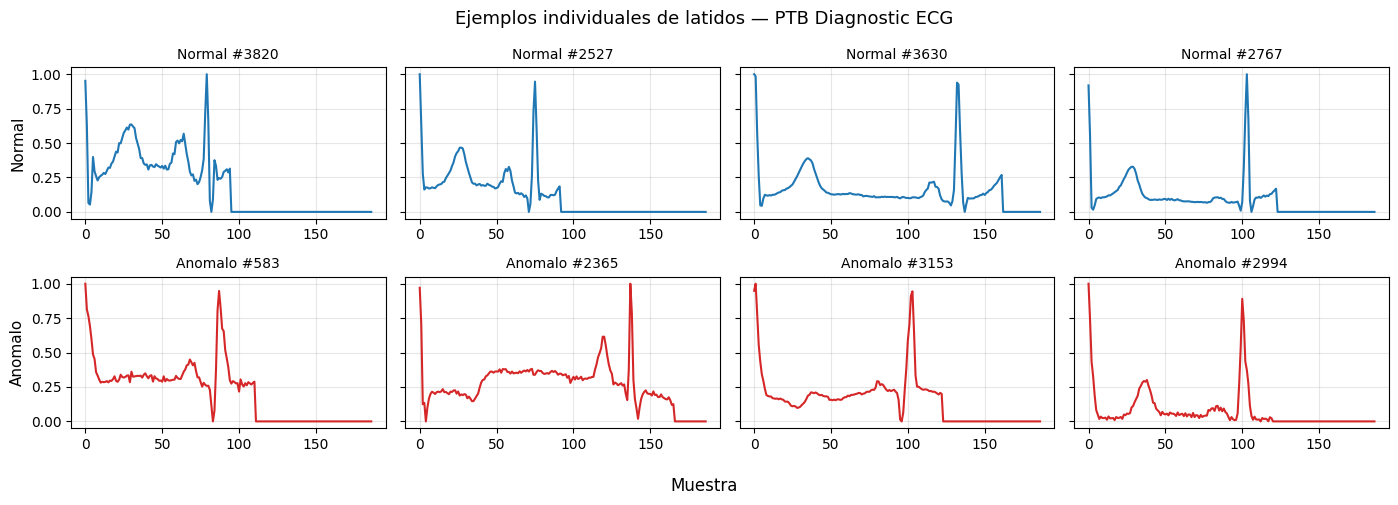

Nota: cada latido tiene su pico R en una posicion distinta del eje X
(el dataset no viene alineado por pico), por eso una superposicion de
muchas señales se ve mas caotica de lo que cada latido individual realmente es.


In [23]:
N_EXAMPLES = 4  # señales de ejemplo por clase

fig, axes = plt.subplots(2, N_EXAMPLES, figsize=(14, 5), sharey=True)

rng = np.random.default_rng(7)
normal_idx = rng.choice(len(normal_vect), N_EXAMPLES, replace=False)
abnormal_idx = rng.choice(len(abnormal_vect), N_EXAMPLES, replace=False)

for col, i in enumerate(normal_idx):
    axes[0, col].plot(normal_vect[i], color='tab:blue')
    axes[0, col].set_title(f'Normal #{i}', fontsize=10)
    axes[0, col].grid(alpha=0.3)

for col, i in enumerate(abnormal_idx):
    axes[1, col].plot(abnormal_vect[i], color='tab:red')
    axes[1, col].set_title(f'Anomalo #{i}', fontsize=10)
    axes[1, col].grid(alpha=0.3)

axes[0, 0].set_ylabel('Normal', fontsize=11)
axes[1, 0].set_ylabel('Anomalo', fontsize=11)
for ax in axes.flat:
    ax.set_ylim(-0.05, 1.05)

fig.suptitle('Ejemplos individuales de latidos — PTB Diagnostic ECG', fontsize=13)
fig.supxlabel('Muestra')
plt.tight_layout()
plt.show()

print("Nota: cada latido tiene su pico R en una posicion distinta del eje X")
print("(el dataset no viene alineado por pico), por eso una superposicion de")
print("muchas señales se ve mas caotica de lo que cada latido individual realmente es.")


### Etiquetado, Partición y Exportación de datasets

A continuación, prepararemos los conjuntos de datos definitivos para el entrenamiento y evaluación de nuestra red neuronal. Realizaremos tres pasos clave:

1. **Etiquetado:** Asignamos la clase `0` a los latidos normales y la clase `1` a los anómalos.
2. **División (Train / Test):** Extraemos un conjunto de prueba **estrictamente balanceado** (1,000 muestras por clase) para asegurar una evaluación objetiva. Las muestras restantes conformarán el set de entrenamiento.
3. **Almacenamiento:** Mezclamos aleatoriamente los datos y los exportamos a formato `.csv` para su uso en las siguientes etapas del taller.

In [24]:
# ============================================================
# 1. Asignación de Etiquetas (0: Normal, 1: Anómalo)
# ============================================================
df_normal = pd.DataFrame(normal_vect)
df_normal['class'] = 0

df_abnormal = pd.DataFrame(abnormal_vect)
df_abnormal['class'] = 1

# ============================================================
# 2. Partición de Datos (Train / Test)
# ============================================================
# Definimos una cantidad fija y balanceada para el set de prueba
n_samples = min(1000, len(df_normal), len(df_abnormal))
print(f'Muestras reservadas para Test (por clase): {n_samples}')

# Muestreo aleatorio para Test
test_normal = df_normal.sample(n=n_samples, random_state=45)
test_abnormal = df_abnormal.sample(n=n_samples, random_state=45)

# Lo que sobra va para Entrenamiento
train_normal = df_normal.drop(test_normal.index)
train_abnormal = df_abnormal.drop(test_abnormal.index)

# ============================================================
# 3. Concatenación y Mezcla (Shuffle)
# ============================================================
# Unimos, mezclamos (frac=1) y reseteamos el índice
test_df = pd.concat([test_normal, test_abnormal], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
train_df = pd.concat([train_normal, train_abnormal], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

# Generamos un dataset reducido para pruebas específicas (UDMA)
test_udma = pd.concat([df_normal.head(100), df_abnormal.head(100)], axis=0)

# ============================================================
# 4. Exportar a formato CSV
# ============================================================
# Nos aseguramos de que la carpeta exista para evitar errores
output_dir = 'dataset'
os.makedirs(output_dir, exist_ok=True) 

test_df.to_csv(f'{output_dir}/test_dataset.csv', index=False)
test_udma.to_csv(f'{output_dir}/test_udma_dataset.csv', index=False)
train_df.to_csv(f'{output_dir}/train_dataset.csv', index=False)
train_normal.to_csv(f'{output_dir}/train_normal_dataset.csv', index=False)
train_abnormal.to_csv(f'{output_dir}/train_abnormal_dataset.csv', index=False)

print(f'Archivos CSV exportados correctamente en: /{output_dir}')

Muestras reservadas para Test (por clase): 1000
Archivos CSV exportados correctamente en: /dataset


In [25]:
# ============================================================
# Verificación y Resumen de los Datasets
# ============================================================

# Resumen de Entrenamiento
print(f"TRAIN SET: {train_df.shape[0]} muestras totales")
print(f"   - Clase 0 (Normal)  : {train_df['class'].value_counts()[0]:,}")
print(f"   - Clase 1 (Anómalo) : {train_df['class'].value_counts()[1]:,}")
print("-" * 45)

# Resumen de Prueba
print(f"TEST SET:  {test_df.shape[0]} muestras totales (Balanceado)")
print(f"   - Clase 0 (Normal)  : {test_df['class'].value_counts()[0]:,}")
print(f"   - Clase 1 (Anómalo) : {test_df['class'].value_counts()[1]:,}")
print("=" * 45)

TRAIN SET: 12552 muestras totales
   - Clase 0 (Normal)  : 3,046
   - Clase 1 (Anómalo) : 9,506
---------------------------------------------
TEST SET:  2000 muestras totales (Balanceado)
   - Clase 0 (Normal)  : 1,000
   - Clase 1 (Anómalo) : 1,000


**Siguiente paso:**

*P1_TF_Training_ECG.ipynb* Donde estableceremos la topologia y realizaremos el entrenamiento de la red neuronal Teacher